In [3]:
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial import cKDTree
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from helpers import *

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

In [3]:
# File paths
comparison_path = f"../output/MERSCOPE_WT_AD_comparison/"

### 1. Data preparation

In [4]:
# ==================== Read data ==================== #

# -------------------- Spots -------------------- #
spots_WT = sc.read_h5ad(f"../data/MERSCOPE_WT_1/processed_data/spots.h5ad")
spots_AD = sc.read_h5ad(f"../data/MERSCOPE_AD_1/processed_data/spots.h5ad")

# Adjust coordinates
spots_WT.obs["global_x_adjusted"] = spots_WT.obs["global_y_new"].copy()
spots_WT.obs["global_y_adjusted"] = spots_WT.obs["global_x_new"].copy()
spots_WT.obs["global_x"] = spots_WT.obs["global_x_adjusted"].copy()
spots_WT.obs["global_y"] = spots_WT.obs["global_y_adjusted"].copy()

spots_AD.obs["global_x_adjusted"] = spots_AD.obs["global_x_new"].copy()
spots_AD.obs["global_y_adjusted"] = spots_AD.obs["global_y_new"].copy()
spots_AD.obs["global_x_adjusted"] += 12000
spots_AD.obs["global_y_adjusted"] += 7200
spots_AD.obs["global_x"] = spots_AD.obs["global_x_adjusted"].copy()
spots_AD.obs["global_y"] = spots_AD.obs["global_y_adjusted"].copy()

# Merge spots
spots_dict = {"MERSCOPE_WT_1": spots_WT, "MERSCOPE_AD_1": spots_AD}
spots_raw = anndata.concat(spots_dict, axis = 0, merge = "same", label = "batch")

# -------------------- Cells -------------------- #
adata_1 = sc.read_h5ad(f"../data/MERSCOPE_WT_1/processed_data/adata.h5ad")
adata_2 = sc.read_h5ad(f"../data/MERSCOPE_AD_1/processed_data/adata.h5ad")

# Adjust coordinates
adata_1.obs["global_x_adjusted"] = adata_1.obs["global_y_new"].copy()
adata_1.obs["global_y_adjusted"] = adata_1.obs["global_x_new"].copy()
adata_1.obs["global_x"] = adata_1.obs["global_x_adjusted"].copy()
adata_1.obs["global_y"] = adata_1.obs["global_y_adjusted"].copy()

adata_2.obs["global_x_adjusted"] = adata_2.obs["global_x_new"].copy()
adata_2.obs["global_y_adjusted"] = adata_2.obs["global_y_new"].copy()
adata_2.obs["global_x_adjusted"] += 12000
adata_2.obs["global_y_adjusted"] += 7200
adata_2.obs["global_x"] = adata_2.obs["global_x_adjusted"].copy()
adata_2.obs["global_y"] = adata_2.obs["global_y_adjusted"].copy()

# Merge cells
adata_dict = {"MERSCOPE_WT_1": adata_1, "MERSCOPE_AD_1": adata_2}
adata = anndata.concat(adata_dict, axis = 0, merge = "same", label = "batch")
adata.write_h5ad(comparison_path + "neuropil_subdomains_adata.h5ad")

# -------------------- Transcripts -------------------- #
theta_WT = 10 * np.pi / 180
theta_AD = 170 * np.pi / 180

transcripts_WT = pd.read_parquet(f"../data/MERSCOPE_WT_1/processed_data/transcripts.parquet")
rotation_matrix = np.array([[np.cos(theta_WT), np.sin(theta_WT)], [-np.sin(theta_WT), np.cos(theta_WT)]])
coords = transcripts_WT[["global_y", "global_x"]].to_numpy()
transformed_coords = coords @ rotation_matrix.T
transcripts_WT["global_y_new"] = transformed_coords[:, 0]
transcripts_WT["global_x_new"] = transformed_coords[:, 1]
transcripts_WT["global_y_new"] = 6250 - transcripts_WT["global_y_new"]

transcripts_WT["global_x"] = transcripts_WT["global_y_new"].copy()
transcripts_WT["global_y"] = transcripts_WT["global_x_new"].copy()

del transcripts_WT["global_x_new"]
del transcripts_WT["global_y_new"]

transcripts_AD = pd.read_parquet(f"../data/MERSCOPE_AD_1/processed_data/transcripts.parquet")
rotation_matrix = np.array([[np.cos(theta_AD), np.sin(theta_AD)], [-np.sin(theta_AD), np.cos(theta_AD)]])
coords = transcripts_AD[["global_x", "global_y"]].to_numpy()
transformed_coords = coords @ rotation_matrix.T
transcripts_AD["global_x_new"] = transformed_coords[:, 0]
transcripts_AD["global_y_new"] = transformed_coords[:, 1]

transcripts_AD["global_x"] = transcripts_AD["global_x_new"].copy()
transcripts_AD["global_y"] = transcripts_AD["global_y_new"].copy()
transcripts_AD["global_x"] += 12000
transcripts_AD["global_y"] += 7200

del transcripts_AD["global_x_new"]
del transcripts_AD["global_y_new"]

# Merge transcripts
transcripts_WT["batch"] = "MERSCOPE_WT_1"
transcripts_AD["batch"] = "MERSCOPE_AD_1"
transcripts = pd.concat([transcripts_WT, transcripts_AD], axis = 0)
transcripts.to_parquet(comparison_path + "neuropil_subdomains_transcripts.parquet")

# -------------------- Granules -------------------- #
granule_adata = sc.read_h5ad(comparison_path + "granule_adata_tsne.h5ad")
granule_subtype_df = pd.read_parquet(comparison_path + "granule_subtype_labels_granule_adata_tsne.parquet")
granule_subtype_df.index = granule_subtype_df.index.astype(str)
granule_adata.obs["granule_subtype_kmeans"] = granule_subtype_df["granule_subtype_kmeans"].astype("category")
granule_adata.obs["granule_subtype_manual"] = granule_subtype_df["granule_subtype_manual"].astype("category")
granule_adata.obs["granule_subtype"] = granule_subtype_df["granule_subtype_manual_simple"].astype("category")

# Manually adjust the x-axis for WT sample
mask = granule_adata.obs["batch"] == "MERSCOPE_WT_1"
granule_adata.obs.loc[mask, "global_x_adjusted"] = (6250 - granule_adata.obs.loc[mask, "global_x_adjusted"])
granule_adata.write_h5ad(comparison_path + "neuropil_subdomains_granule_adata.h5ad")

In [5]:
# Enhance spatial resolution
spots = subdivide_spots(spots_raw)

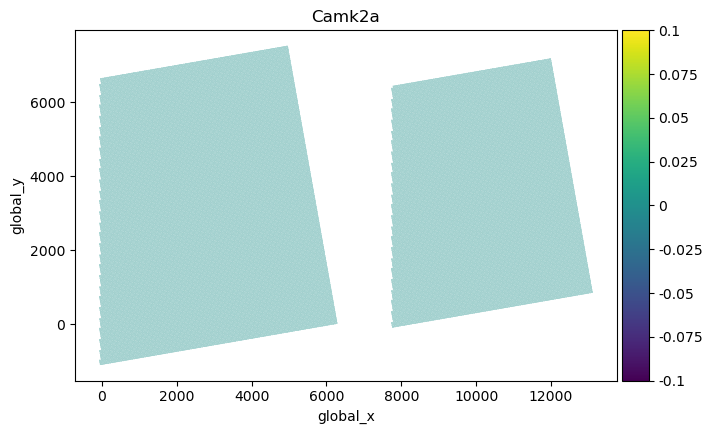

In [6]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="Camk2a")

In [7]:
spots = fill_spot_expression(
    spots, transcripts, grid_len=25.0, assign_to="all_transcripts"
)

Processed 0 out of 290 genes!
Processed 10 out of 290 genes!


KeyboardInterrupt: 

In [4]:
transcripts_WT = pd.read_parquet(f"../data/MERSCOPE_WT_1/processed_data/transcripts.parquet")
transcripts_WT

,cell_id,overlaps_nucleus,target,global_x,global_y,global_z
0,-1,0,Inpp4b,133.08844,2717.2595,0.0
1,-1,0,Inpp4b,187.72237,2653.8596,1.5
2,4388284201180100135,0,Inpp4b,69.97584,2656.0925,1.5
3,-1,0,Inpp4b,170.35840,2744.3406,1.5
4,-1,0,Gfap,90.94957,2735.0588,3.0
...,...,...,...,...,...,...
201906933,-1,0,Inpp4b,7430.12000,4339.4020,1.5
201906934,-1,0,Inpp4b,7439.49500,4259.2250,3.0
201906935,-1,0,Nefm,7291.01200,4406.8670,6.0
201906936,4388284202003100298,0,Nr2f2,7425.08740,4341.2197,6.0


In [5]:
transcripts_WT["overlaps_nucleus"].mean()

0.2789093022511794

In [ ]:
spots.layers["all_transcripts"]

In [ ]:
# Compute grid-level embeddings
embeddings, feature_names = spot_embedding_granule_composition(
    spots=spots,
    granule_adata=granule_adata,
    adata=adata,
    spot_width=25,
    spot_height=25,
    include_soma_density=True,
    smoothing=True,
    smoothing_k=9,
    smoothing_mode="mean"
)

In [ ]:
embeddings.shape

In [ ]:
feature_names

In [ ]:
X = embeddings[:, :-1]  # exclude soma_density for now
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
k = 5
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X_scaled)

In [ ]:
spots.obs["soma_density"] = embeddings[:, -1]

spots.obs["subdomain"] = labels.astype(str)
spots.obs["subdomain"].value_counts()

In [ ]:
del spots.uns["subdomain_colors"]
sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain", title="Subdomains")

In [ ]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="soma_density", title="Subdomains")